In [33]:
# Setup
# Cell 1: Setup
import data_loader
import importlib
importlib.reload(data_loader)


# print(f"Box size1: {BOX_SIZE}")

# Setup
from data_loader import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

print("BOX_SIZE2:", BOX_SIZE)


plt.rcParams.update({'font.size': 14})


df_corrected.head()

Loading bubble data...
✓ Loaded 139446 observations
✓ Timesteps added: 0 to 725
✓ Identified 300 disappearing bubbles
Applying periodic boundary corrections...
✓ Periodic boundary correction applied
✓ Derived quantities computed

DATA LOADING COMPLETE
Total observations:       139,446
Unique bubbles:           400
Timesteps:                0 to 725
Disappearing bubbles:     300
Box size:                 20.203051
Initial avg area (A_0):   1.000000

Available variables:
  - df: Original dataframe
  - df_corrected: Corrected dataframe with actual_area column
  - disappearing_ids: Set of disappearing bubble IDs
  - bubbles_per_timestep: Number of bubbles at each timestep
  - avg_area_per_timestep: Average bubble area at each timestep
  - approx_avg_area: Approximate area from liquid fraction
  - A_0: Initial average bubble area
  - max_timestep: Maximum timestep
  - final_step: Final timestep
  - box_area: Total box area
  - BOX_SIZE, PERIODIC_THRESHOLD, LIQUID_FRACTION: Constants

BOX_SI

,id,x,y,area,pressure,Z,timestep,actual_area
0,1,16.830467,10.024328,1.505199,1.051348,16,0,7.117668
1,2,10.836769,7.222546,0.273170,2.395116,5,0,0.234431
2,3,8.349003,1.681417,1.030034,1.177891,9,0,3.333136
3,4,1.364649,6.059485,0.298862,2.014220,5,0,0.280602
4,5,1.334989,3.429860,0.151537,3.716496,4,0,0.072142


Δt=1: n=278092, mean=0.00000, var=0.00021
Δt=10: n=270912, mean=0.00008, var=0.00502
Δt=50: n=241614, mean=0.00134, var=0.03075
Δt=150: n=183692, mean=0.00792, var=0.09558


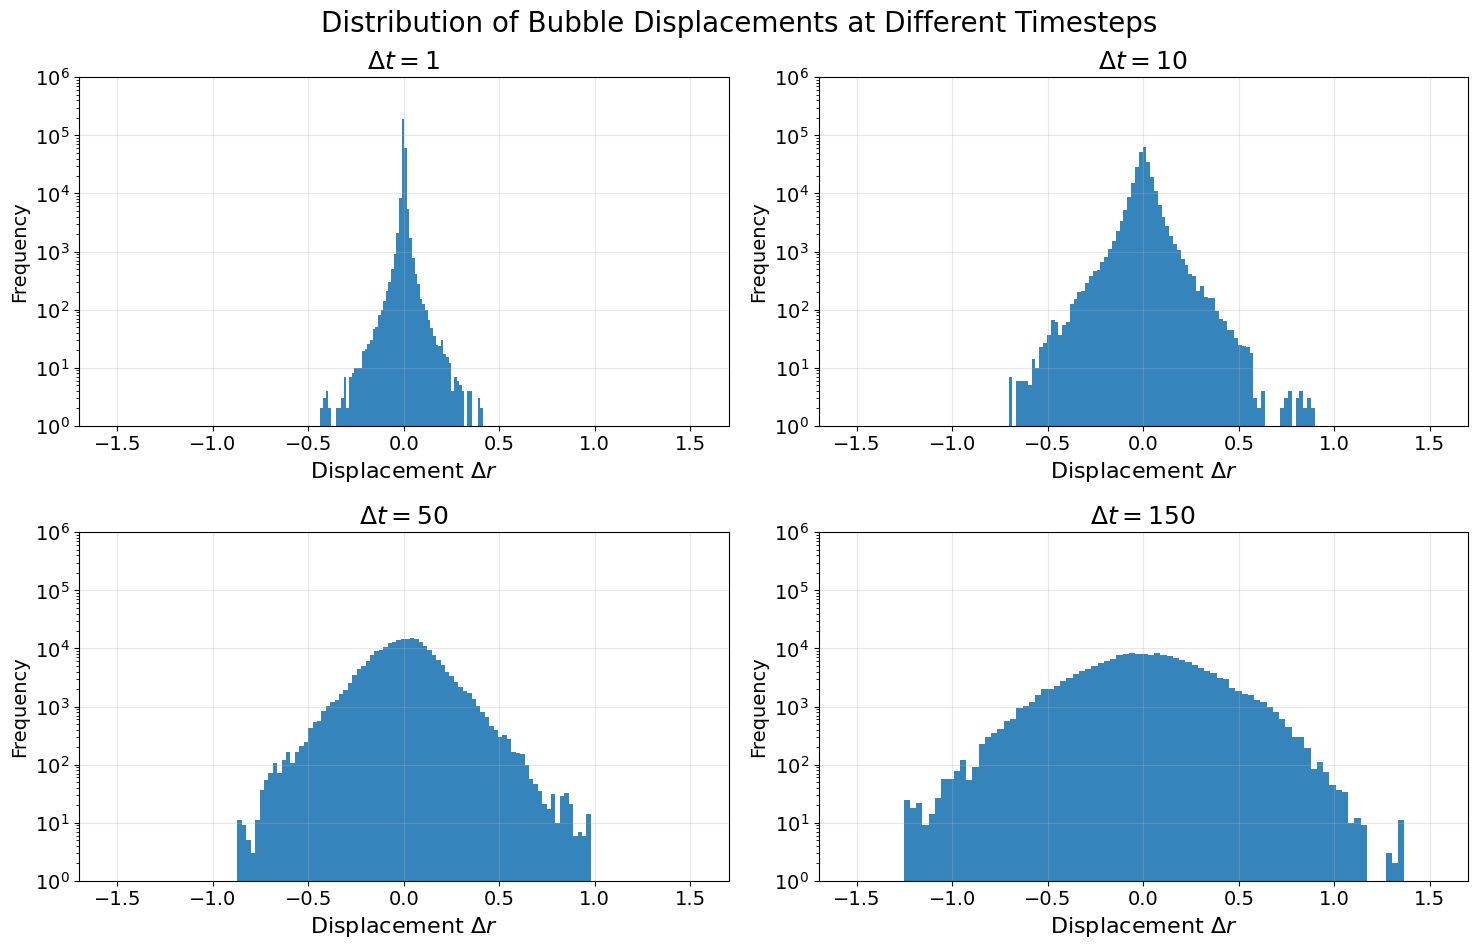

Z values for each dt:
Δt=1: Z=0.00001
Δt=10: Z=0.00002
Δt=50: Z=0.00007
Δt=150: Z=0.00012


In [34]:
# Make Displacement Distribution Data

# Displacement Analysis for Multiple dt Values
dt_values = [1, 10, 50, 150]
Z_list = [] # Peak heights for each time lag

fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.ravel()
plt.suptitle('Distribution of Bubble Displacements at Different Timesteps', 
             fontsize=20, y=0.95)

for idx, dt in enumerate(dt_values):
    all_dx, all_dy = [], []
    
    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        
        if len(x) <= dt:
            continue
        
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)
    
    all_disp = np.concatenate([all_dx, all_dy])
    counts, bins, patches = axs[idx].hist(all_disp, bins=80, alpha=0.9)
    axs[idx].set_title(rf"$\Delta t = {dt}$", fontsize=18)
    axs[idx].grid(alpha=0.3)
    axs[idx].set_yscale('log')
    axs[idx].set_xlim(-1.7, 1.7)
    axs[idx].set_ylim(1, 1e6)
    axs[idx].set_xlabel(r"Displacement $\Delta r$", fontsize=16)
    axs[idx].set_ylabel("Frequency")

    Z = 1/max(counts)
    Z_list.append(Z)
    
    print(f"Δt={dt}: n={len(all_disp)}, mean={np.mean(all_disp):.5f}, var={np.var(all_disp):.5f}")

plt.tight_layout(rect=[0, 0, 1, 0.98])
# plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/03_Figures/displacement_distributions_2.png", dpi=300, bbox_inches='tight')
plt.show()

# print Z values
print("Z values for each dt:")
for dt, Z in zip(dt_values, Z_list):
    print(f"Δt={dt}: Z={Z:.5f}")


/var/folders/l1/x0797x3512d9sktcpm47npbh0000gn/T/ipykernel_17253/1066186376.py:50: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e6)  # adjust if needed after you pick top_peak


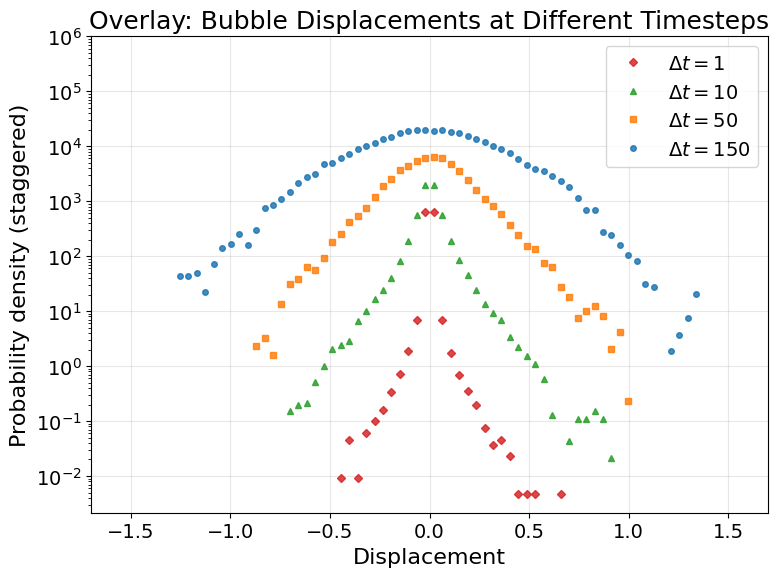

In [35]:

# Overlay with centred x and staggered (log) peaks
plt.figure(figsize=(8, 6))

markers = ['o', 's', '^', 'D', 'v', 'x']

# make sure order is from largest dt (highest) to smallest dt (lowest)
dt_plot_order = sorted(dt_values, reverse=True)

# choose where you want the top peak to sit and how much to separate peaks (in log10 decades)
top_peak = 2e4        # try 2e4 or 5e4 depending on your ylim
decade_step = 0.50    # ~0.50 decades separation (~3.16x in linear). Tweak to taste.

for idx, dt in enumerate(dt_plot_order):
    all_dx, all_dy = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)

    # concatenate and centre so the peak sits at x ~ 0
    all_disp = np.concatenate([all_dx, all_dy])
    all_disp -= all_disp.mean()

    # histogram as a probability density (PDF)
    bins = 80
    rng = (-1.7, 1.7)
    counts, bin_edges = np.histogram(all_disp, bins=bins, range=rng, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # scale so that peaks are staggered on a log axis
    current_peak = counts.max() if counts.max() > 0 else 1.0
    target_peak = top_peak * (10 ** (-decade_step * idx))  # 700 highest, then step down
    scale = target_peak / current_peak
    counts_scaled = counts * scale

    plt.plot(
        bin_centers, counts_scaled,
        marker=markers[idx % len(markers)], linestyle='none',
        label=rf'$\Delta t = {dt}$', alpha=0.85, markersize=4
    )

plt.yscale('log')
plt.xlim(-1.7, 1.7)
plt.ylim(0, 1e6)  # adjust if needed after you pick top_peak
plt.xlabel(r"Displacement", fontsize=16)
plt.ylabel("Probability density (staggered)", fontsize=16)
plt.title("Overlay: Bubble Displacements at Different Timesteps", fontsize=18)
plt.grid(alpha=0.3)
plt.legend(loc="upper right")
# reverse legend order
handles, labels = plt.gca().get_legend_handles_labels()
plt.gca().legend(handles[::-1], labels[::-1], loc="upper right")
plt.tight_layout()
# plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/03_Figures/displacement_overlay_shifted_peaks.png", dpi=300, bbox_inches='tight')
plt.show()

# reverse legend order
# change dt's

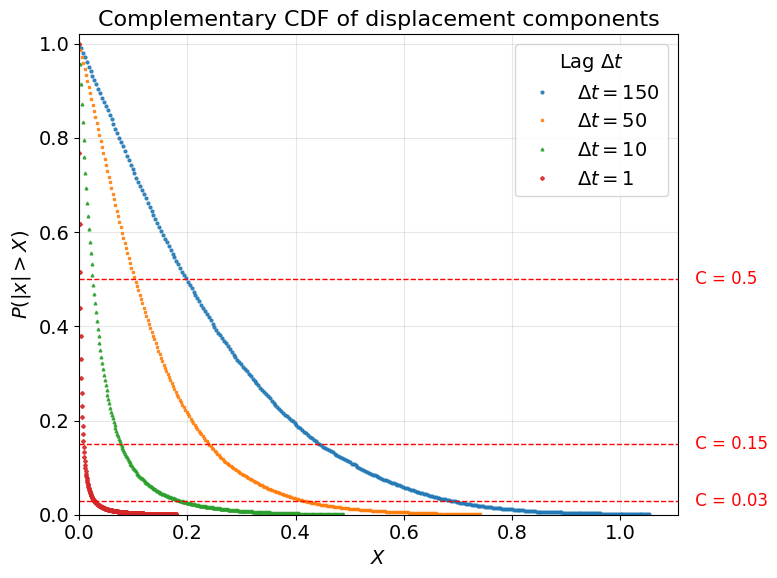

In [36]:

plt.figure(figsize=(8, 6))
markers = ['o', 's', '^', 'D', 'v', 'x']

# Choose the C (probability) levels for horizontal cuts
C_vals = [0.50, 0.15, 0.03]

# Plot largest dt first so it is on top in legend
dt_plot_order = sorted(dt_values, reverse=True)

for idx, dt in enumerate(dt_plot_order):
    all_dx, all_dy = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)

    # radial step sizes:
    # disp = np.sqrt(np.array(all_dx)**2 + np.array(all_dy)**2)
    disp = np.concatenate([all_dx, all_dy])

    vals = np.abs(disp) 
    vals_sorted = np.sort(vals)
    n = vals_sorted.size

    # A smooth X grid up to the 99.9th percentile
    X = np.linspace(0, np.quantile(vals_sorted, 0.999), 300)

    # Empirical CCDF: P(|x| > X)
    F = np.searchsorted(vals_sorted, X, side='right') / n 
    CCDF = 1.0 - F

    plt.plot(
        X, CCDF, marker=markers[idx % len(markers)],
        linestyle='none', ms=2, alpha=0.85,
        label=rf'$\Delta t = {dt}$'
    )

# Dashed lines for C values
for C in C_vals:
    plt.axhline(y=C, color='red', linestyle='--', linewidth=1)
    plt.text(
        1.02 * plt.xlim()[1], C, f" C = {C}",
        va='center', ha='left', fontsize=12, color='red'
    )

# Axis scaling and labels
plt.ylim(0, 1.02)
plt.xlim(left=0)
plt.ylabel(r"$P(|x|>X)$", fontsize=14)
plt.xlabel(r"$X$", fontsize=14)
plt.title("Complementary CDF of displacement components", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(title=r"Lag $\Delta t$")
plt.tight_layout()
# plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/03_Figures/ccdf_displacement_components_2.png", dpi=300, bbox_inches='tight')
plt.show()

# do it with simpsons and trapeziodal rule too

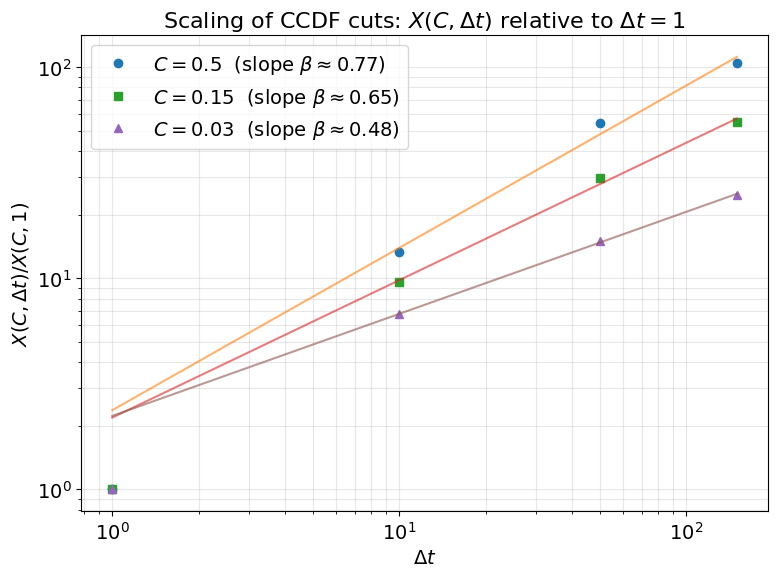

In [37]:
# === Horizontal cuts of CCDF and scaling plot ===

# choose the C levels
C_vals = [0.50, 0.15, 0.03]   

radial = False  # True = use r = sqrt(dx^2+dy^2), False = use |component| (Δx & Δy pooled)

def get_abs_displacements(dt):
    """Return |x| sample used in CCDF: either radial or component magnitude."""
    all_dx, all_dy = [], []
    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)
    all_dx = np.asarray(all_dx)
    all_dy = np.asarray(all_dy)
    if radial:
        vals = np.sqrt(all_dx**2 + all_dy**2)
    else:
        vals = np.abs(np.concatenate([all_dx, all_dy]))
    return np.abs(vals)

# ensure dt=1 exists as the normalization reference
dt_plot_order = sorted(dt_values)
#assert dt_plot_order[0] == 1 or 1 in dt_plot_order, "Need Δt=1 in dt_values to form the ratio."

# precompute |x| samples for each Δt once (can be large)
abs_samples = {dt: get_abs_displacements(dt) for dt in dt_plot_order if len(get_abs_displacements(dt))}

# compute X(C, dt) for each level and dt
X_C_dt = {C: {} for C in C_vals}
for C in C_vals:
    q = 1.0 - C  # CCDF level C corresponds to quantile q=1-C
    for dt, vals in abs_samples.items():
        if len(vals) == 0:
            continue
        X_C_dt[C][dt] = float(np.quantile(vals, q))

# make the scaling plot: X(C, dt) / X(C, 1) vs dt
plt.figure(figsize=(8, 6))
markers = ['o', 's', '^', 'D', 'v', 'x']

for i, C in enumerate(C_vals):
    dts = np.array(sorted(X_C_dt[C].keys()))
    Xs  = np.array([X_C_dt[C][dt] for dt in dts])
    # normalize by dt=1 value (guard if missing)
    if 1 not in X_C_dt[C]:
        raise ValueError("dt=1 missing; cannot normalize.")
    X1 = X_C_dt[C][1]
    ratio = Xs / X1

    # log–log fit 
    # ratio ≈ A * dt^beta  => log(ratio) = log(A) + beta*log(dt)
    mask = dts != 1         # exclude dt==1;
    dts_fit = dts[mask]
    ratio_fit = ratio[mask]

    beta, logA = np.polyfit(np.log(dts_fit), np.log(ratio_fit), 1)[0], np.polyfit(np.log(dts_fit), np.log(ratio_fit), 1)[1]
    A = np.exp(logA)
    fit_curve = A * dts**beta

    plt.loglog(dts, ratio, marker=markers[i % len(markers)], linestyle='none',
               label=fr'$C={C}$  (slope $\beta\approx{beta:.2f}$)')
    plt.loglog(dts, fit_curve, linestyle='-', alpha=0.6)

plt.xlabel(r'$\Delta t$', fontsize=14)
plt.ylabel(r'$X(C,\Delta t)/X(C,1)$', fontsize=14)
plt.title('Scaling of CCDF cuts: $X(C,\Delta t)$ relative to $\Delta t=1$', fontsize=16)
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
# plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/03_Figures/ccdf_cut_scaling_2.png", dpi=300, bbox_inches='tight')
plt.show()

# try plotting log of data

## alpha = 1/beta
We will take an average beta 0.65

alpha = 1.54

In [43]:
from scipy.optimize import curve_fit
import numpy as np

def p_model(x, beta, alpha, Z):
    return (1.0 / Z) * (1.0 + (beta * x**2) / alpha) ** (-alpha)

def estimate_Z0_from_pdf(bin_centers, pdf):
    i0 = np.argmin(np.abs(bin_centers))     # bin closest to 0
    P0 = pdf[i0]
    if P0 <= 0:
        raise ValueError("P(0) estimate <= 0. Try more bins or adjust range.")
    return 1.0 / P0, P0, i0

def fit_beta_one_param(bin_centers, pdf, alpha, Z0, fit_window_quantile=0.98):
    # Fit mostly the central region (stabilises the fit)
    xmax = np.quantile(np.abs(bin_centers), fit_window_quantile)
    mask = (np.abs(bin_centers) <= xmax) & (pdf > 0)
    x_fit = bin_centers[mask]
    y_fit = pdf[mask]

    def model_beta_only(x, beta):
        return p_model(x, beta=beta, alpha=alpha, Z=Z0)

    # rough starting guess
    beta0 = alpha / np.mean(x_fit**2)

    popt, pcov = curve_fit(model_beta_only, x_fit, y_fit, p0=[beta0], maxfev=20000)
    beta_hat = popt[0]
    beta_err = np.sqrt(pcov[0, 0]) if pcov.size else np.nan
    return beta_hat, beta_err

def fit_beta_Z_two_param(bin_centers, pdf, alpha, beta0, Z0, fit_window_quantile=0.98):
    xmax = np.quantile(np.abs(bin_centers), fit_window_quantile)
    mask = (np.abs(bin_centers) <= xmax) & (pdf > 0)
    x_fit = bin_centers[mask]
    y_fit = pdf[mask]

    def model_beta_Z(x, beta, Z):
        return p_model(x, beta=beta, alpha=alpha, Z=Z)

    bounds = ([0.0, 0.0], [np.inf, np.inf])

    popt, pcov = curve_fit(
        model_beta_Z, x_fit, y_fit,
        p0=[beta0, Z0],
        bounds=bounds,
        maxfev=40000
    )
    beta_hat, Z_hat = popt
    beta_err, Z_err = np.sqrt(np.diag(pcov))
    return beta_hat, beta_err, Z_hat, Z_err

In [45]:
alpha_fixed = 1.54   # <-- replace with your alpha
do_two_param = True  # set False if you only want the 1-param beta fit

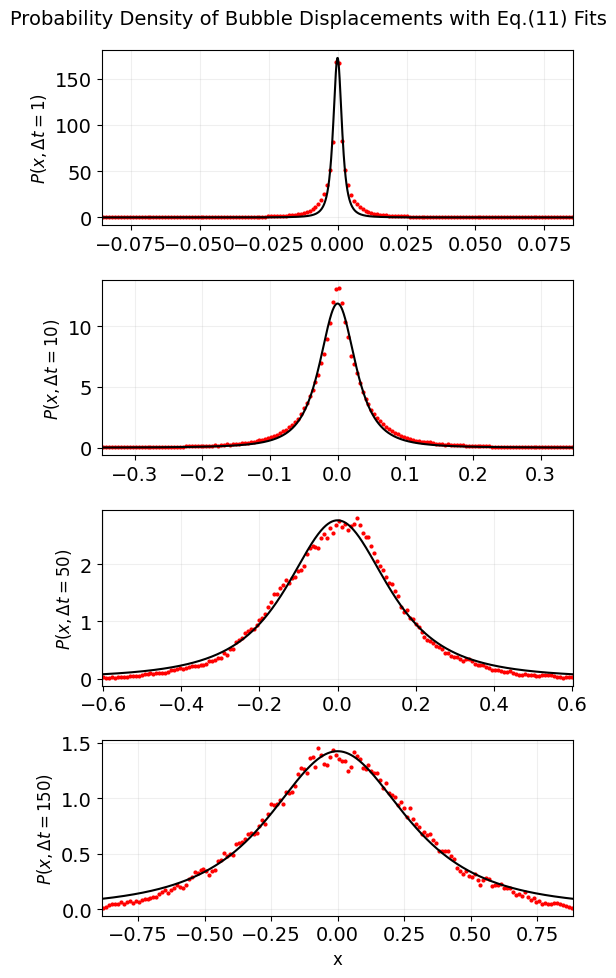

In [ ]:
alpha_fixed = 1.56      # <-- your alpha
do_two_param = True     # paper: yes (after 1-param)
bins = 160
x_cut_quantile = 0.995
fit_window_quantile = 0.98

dt_plot_order = sorted(dt_values)   # paper shows increasing t down the page

fig, axes = plt.subplots(len(dt_plot_order), 1, figsize=(6, 10), sharex=False)
if len(dt_plot_order) == 1:
    axes = [axes]

fit_results = []

for ax, dt in zip(axes, dt_plot_order):
    all_dx, all_dy = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        x, y = g["x"].to_numpy(), g["y"].to_numpy()
        if len(x) <= dt:
            continue
        dx_dt = x[dt:] - x[:-dt]
        dy_dt = y[dt:] - y[:-dt]
        all_dx.extend(dx_dt)
        all_dy.extend(dy_dt)

    all_disp = np.concatenate([all_dx, all_dy])
    all_disp = all_disp[np.isfinite(all_disp)]
    all_disp -= np.mean(all_disp)  # center like paper

    # choose x-range per dt from quantile (like paper’s varying x-limits)
    xmax = np.quantile(np.abs(all_disp), x_cut_quantile)
    rng = (-xmax, xmax)

    pdf, edges = np.histogram(all_disp, bins=bins, range=rng, density=True)
    xc = 0.5 * (edges[:-1] + edges[1:])

    # fit (on TRUE pdf)
    Z0, P0, i0 = estimate_Z0_from_pdf(xc, pdf)
    beta1, beta1_err = fit_beta_one_param(xc, pdf, alpha=alpha_fixed, Z0=Z0,
                                          fit_window_quantile=fit_window_quantile)

    if do_two_param:
        beta2, beta2_err, Z2, Z2_err = fit_beta_Z_two_param(
            xc, pdf, alpha=alpha_fixed, beta0=beta1, Z0=Z0,
            fit_window_quantile=fit_window_quantile
        )
        beta_use, Z_use = beta2, Z2
    else:
        beta2 = beta2_err = Z2 = Z2_err = None
        beta_use, Z_use = beta1, Z0

    # smooth fit curve
    x_plot = np.linspace(rng[0], rng[1], 1500)
    y_fit = p_model(x_plot, beta=beta_use, alpha=alpha_fixed, Z=Z_use)

    # plot (dots + black line)
    ax.plot(xc, pdf, 'r.', markersize=4)
    ax.plot(x_plot, y_fit, 'k-', linewidth=1.5)

    ax.set_yscale("log")
    ax.set_xlim(rng[0], rng[1])


    ax.set_ylabel(rf"$P(x,\Delta t={dt})$", fontsize=12)
    ax.grid(alpha=0.2)

    fit_results.append({
        "dt": dt,
        "Z0": Z0,
        "beta_1param": beta1,
        "beta_1param_err": beta1_err,
        "beta_2param": beta2,
        "beta_2param_err": beta2_err,
        "Z_2param": Z2,
        "Z_2param_err": Z2_err,
        "xmax_used": xmax
    })

axes[-1].set_xlabel("x", fontsize=12)
fig.suptitle("Probability Density of Bubble Displacements with Eq.(11) Fits", fontsize=14)
plt.tight_layout()
plt.show()

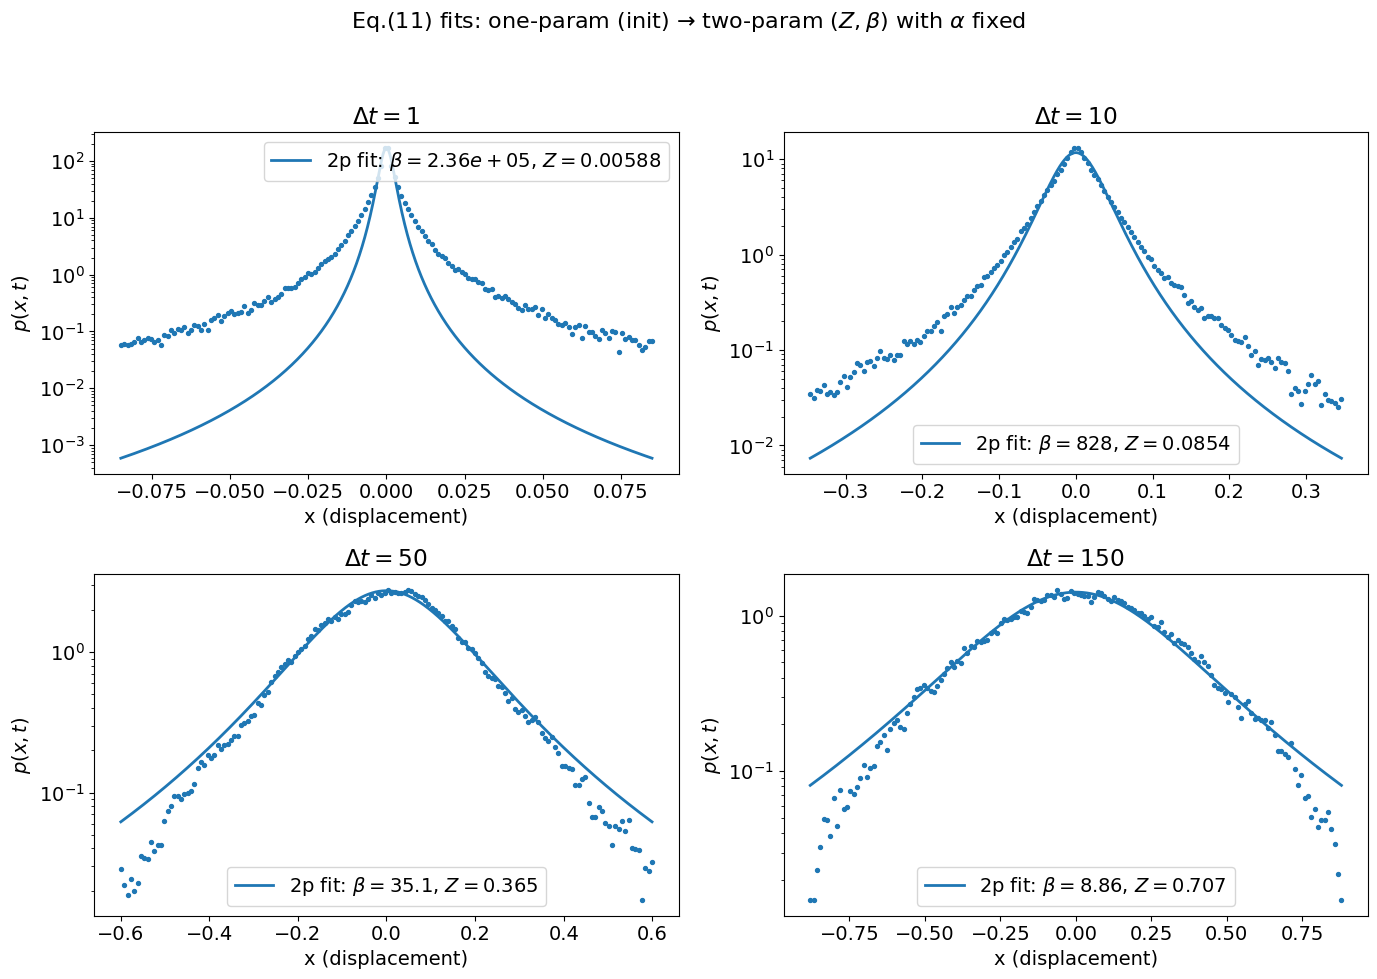


Fit results (two-parameter):
dt=  1: beta_1p(init)=229979, Z0=0.00596026  |  beta_hat=236391 ± 1.1e+04, Z_hat=0.00588198 ± 0.0001
dt= 10: beta_1p(init)=1040.88, Z0=0.0761126  |  beta_hat=828.334 ± 23, Z_hat=0.085427 ± 0.00092
dt= 50: beta_1p(init)=33.0312, Z0=0.378732  |  beta_hat=35.086 ± 0.67, Z_hat=0.364885 ± 0.0027
dt=150: beta_1p(init)=8.4866, Z0=0.72575  |  beta_hat=8.86387 ± 0.17, Z_hat=0.706703 ± 0.005


In [41]:
beta1 = 0.65
alpha_from_beta1 = 1/beta1  # not used below unless you want it

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# -------------------------------
# Model: Eq.(11)
# -------------------------------
def p_model(x, beta, alpha, Z):
    return (1.0 / Z) * (1.0 + (beta * x**2) / alpha) ** (-alpha)


# ---------------------------------------
# One-param: fit ONLY beta, Z fixed from p(0)=1/Z
# (use this ONLY to get initial guesses)
# ---------------------------------------
def fit_beta_one_param_from_pdf(displacements, alpha, nbins=160, x_cut_quantile=0.995):
    displacements = np.asarray(displacements)
    displacements = displacements[np.isfinite(displacements)]
    if displacements.size < 50:
        raise ValueError("Not enough displacement samples to fit.")

    x_max = np.quantile(np.abs(displacements), x_cut_quantile)
    if not np.isfinite(x_max) or x_max <= 0:
        raise ValueError("Bad x_max from quantile; check displacements.")

    bins = np.linspace(-x_max, x_max, nbins + 1)
    p, edges = np.histogram(displacements, bins=bins, density=True)
    x = 0.5 * (edges[:-1] + edges[1:])

    # Z0 from bin nearest zero (rough initial guess)
    i0 = np.argmin(np.abs(x))
    p0 = p[i0]
    if p0 <= 0 or not np.isfinite(p0):
        raise ValueError("p(0) <= 0; try different binning or ensure density=True.")
    Z0 = 1.0 / p0

    mask = (p > 0) & np.isfinite(p) & np.isfinite(x)
    x_fit = x[mask]
    p_fit = p[mask]

    var = np.var(displacements)
    beta_init = alpha / (var + 1e-30)

    def f_oneparam(xvals, beta):
        return p_model(xvals, beta, alpha=alpha, Z=Z0)

    beta_hat, pcov = curve_fit(f_oneparam, x_fit, p_fit, p0=[beta_init], maxfev=20000)
    beta_hat = float(beta_hat[0])
    beta_err = float(np.sqrt(np.diag(pcov))[0]) if pcov.size else np.nan

    return beta_hat, beta_err, Z0, x, p


# ---------------------------------------
# Part A (proper next step): Two-param fit
# Fit Z and beta simultaneously, alpha fixed
# ---------------------------------------
def fit_Z_beta_two_param(x, p, alpha, Z0, beta0, x_fit_quantile=0.995):
    x = np.asarray(x)
    p = np.asarray(p)

    # optionally restrict fit range (helps tails not dominate)
    x_cut = np.quantile(np.abs(x[np.isfinite(x)]), x_fit_quantile)
    mask = (p > 0) & np.isfinite(p) & np.isfinite(x) & (np.abs(x) <= x_cut)

    x_fit = x[mask]
    p_fit = p[mask]

    if x_fit.size < 20:
        raise ValueError("Too few bins to fit after masking. Try fewer restrictions.")

    def f_twoparam(xvals, Z, beta):
        return p_model(xvals, beta, alpha=alpha, Z=Z)

    # enforce positivity (Z>0, beta>0)
    popt, pcov = curve_fit(
        f_twoparam,
        x_fit, p_fit,
        p0=[Z0, beta0],
        bounds=([1e-12, 1e-12], [np.inf, np.inf]),
        maxfev=50000
    )

    Z_hat, beta_hat = map(float, popt)
    perr = np.sqrt(np.diag(pcov)) if pcov.size else np.array([np.nan, np.nan])
    Z_err, beta_err = map(float, perr)

    return Z_hat, Z_err, beta_hat, beta_err


# ---------------------------------------
# Get pooled dx, dy for a given dt
# ---------------------------------------
def pooled_displacements(df_corrected, dt, use_S=False):
    all_d = []
    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep")
        if use_S:
            X = g["Sx"].to_numpy()
            Y = g["Sy"].to_numpy()
        else:
            X = g["x"].to_numpy()
            Y = g["y"].to_numpy()

        if len(X) <= dt:
            continue

        dx = X[dt:] - X[:-dt]
        dy = Y[dt:] - Y[:-dt]

        all_d.append(dx)
        all_d.append(dy)

    if not all_d:
        return np.array([])
    return np.concatenate(all_d)


# =======================================
# MAIN
# =======================================
dt_values = [1, 10, 50, 150]
alpha = 1.84  # keep fixed (or swap to alpha_from_beta1 if you want)

results = {}

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()
fig.suptitle(r"Eq.(11) fits: one-param (init) → two-param ($Z,\beta$) with $\alpha$ fixed", fontsize=16)

for i, dt in enumerate(dt_values):
    disp = pooled_displacements(df_corrected, dt, use_S=False)

    if disp.size == 0:
        print(f"dt={dt}: no data (skipping)")
        continue

    # ---- Step 1: one-free-param fit just for initial guesses ----
    beta_1p, beta_1p_err, Z0, x, p = fit_beta_one_param_from_pdf(
        disp, alpha=alpha, nbins=160, x_cut_quantile=0.995
    )

    # ---- Step 2 (Part A): two-parameter fit for Z and beta ----
    Z_hat, Z_err, beta_hat, beta_err = fit_Z_beta_two_param(
        x, p, alpha=alpha, Z0=Z0, beta0=beta_1p, x_fit_quantile=0.995
    )

    # model curve (using two-param fit)
    x_line = np.linspace(x.min(), x.max(), 2000)
    y_line = p_model(x_line, beta_hat, alpha=alpha, Z=Z_hat)

    results[dt] = {
        "beta_1p": beta_1p,
        "Z0_from_p0": Z0,
        "Z_hat": Z_hat,
        "Z_err": Z_err,
        "beta_hat": beta_hat,
        "beta_err": beta_err
    }

    ax = axs[i]
    ax.scatter(x, p, s=8)
    ax.plot(x_line, y_line, lw=2, label=rf"2p fit: $\beta={beta_hat:.3g}$, $Z={Z_hat:.3g}$")
    ax.set_yscale("log")
    ax.set_title(rf"$\Delta t={dt}$")
    ax.set_xlabel("x (displacement)")
    ax.set_ylabel(r"$p(x,t)$")
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nFit results (two-parameter):")
for dt in dt_values:
    if dt in results:
        r = results[dt]
        print(
            f"dt={dt:>3}: "
            f"beta_1p(init)={r['beta_1p']:.6g}, Z0={r['Z0_from_p0']:.6g}  |  "
            f"beta_hat={r['beta_hat']:.6g} ± {r['beta_err']:.2g}, "
            f"Z_hat={r['Z_hat']:.6g} ± {r['Z_err']:.2g}"
        )